<a href="https://colab.research.google.com/github/iliyasking/Iliyas/blob/main/Build_a_Generative_Adversal_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
torch.manual_seed(42)
import numpy as np
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm

In [2]:
import torch.nn as nn
from torchvision.utils import make_grid

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Hyperparameters
image_size = 28
image_channels = 1
batch_size = 64
noise_dim = 64
num_epochs = 50
lr_D = 0.0002
lr_G = 0.0002
beta_1 = 0.5
beta_2 = 0.999

In [3]:
import torchvision
from torchvision import transforms

# Define the transformation to apply to the images
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

In [4]:
# Load the MNIST training dataset
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 451kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.21MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.8MB/s]


In [5]:
# Load the MNIST test dataset
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=True)

In [6]:
from torch.utils.data import DataLoader

# Create data loaders for the training and test datasets
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

In [7]:
# 'show_tensor_images' : function is used to plot some of images from the batch

def show_tensor_images(tensor_img, num_images = 16, size=(1, 28, 28)):
    unflat_img = tensor_img.detach().cpu()
    # Explicitly normalize the image grid to [0, 1] for display
    img_grid = make_grid(unflat_img[:num_images], nrow=4, normalize=True)
    plt.imshow(img_grid.permute(1, 2, 0).squeeze())
    plt.show()

In [8]:
!pip install torchsummary

In [9]:
class Discriminator(nn.Module):
    def __init__(self, image_channels):
        super(Discriminator, self).__init__()
        self.disc = nn.Sequential(
            # Input: (bs, image_channels, 28, 28)
            nn.Conv2d(image_channels, 16, kernel_size=3, stride=2, padding=1), # Changed padding from 0 to 1
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.2),
            # Output: (bs, 16, 14, 14)

            nn.Conv2d(16, 32, kernel_size=5, stride=2, padding=0),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            # Output: (bs, 32, 5, 5)

            nn.Conv2d(32, 64, kernel_size=5, stride=2, padding=0),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            # Output: (bs, 64, 1, 1)

            nn.Flatten(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.disc(x)

In [10]:
class Generator(nn.Module):
    def __init__(self, noise_dim, image_channels):
        super(Generator, self).__init__()
        self.gen = nn.Sequential(
            # Input: (bs, noise_dim, 1, 1)
            nn.ConvTranspose2d(noise_dim, 256, kernel_size=3, stride=2, padding=0),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            # Output: (bs, 256, 3, 3)

            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=1, padding=0),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            # Output: (bs, 128, 6, 6)

            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=0),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            # Output: (bs, 64, 13, 13)

            nn.ConvTranspose2d(64, image_channels, kernel_size=4, stride=2, padding=0), # padding is already 0 as fixed earlier
            nn.Tanh()
            # Output: (bs, image_channels, 28, 28)
        )

    def forward(self, x):
        return self.gen(x)

In [11]:
def weights_init(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
        nn.init.normal_(m.weight, 0.0, 0.02)
    if isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight, 0.0, 0.02)
        nn.init.constant_(m.bias, 0)

In [12]:
# Initialize Discriminator and Generator
D = Discriminator(image_channels).to(device)
G = Generator(noise_dim, image_channels).to(device)

# Apply weights_init
D.apply(weights_init)
G.apply(weights_init)

# Define the loss function and optimizers
loss_function = nn.BCEWithLogitsLoss()
optimizer_D = torch.optim.Adam(D.parameters(), lr=lr_D, betas=(beta_1, beta_2))
optimizer_G = torch.optim.Adam(G.parameters(), lr=lr_G, betas=(beta_1, beta_2))

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [0/50] Loss D: 0.6705, Loss G: 0.7084


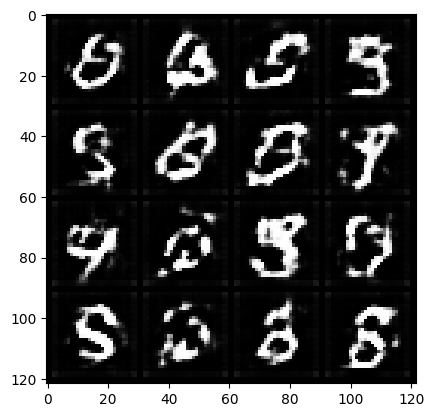

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [1/50] Loss D: 0.6403, Loss G: 0.7591


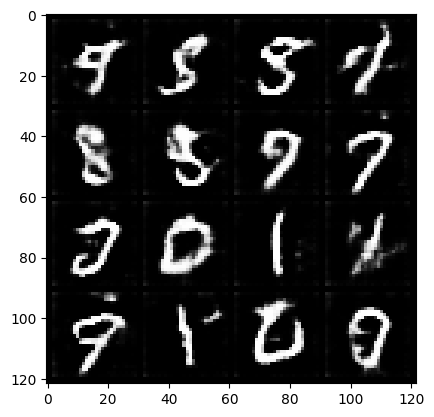

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [2/50] Loss D: 0.6552, Loss G: 0.7491


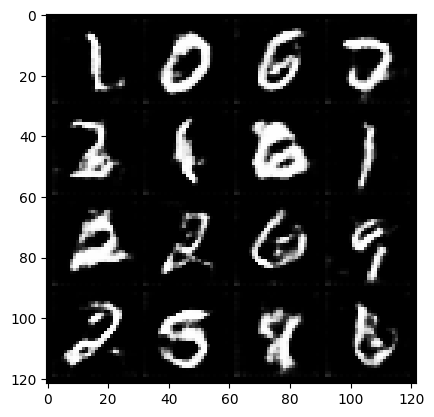

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [3/50] Loss D: 0.6682, Loss G: 0.8116


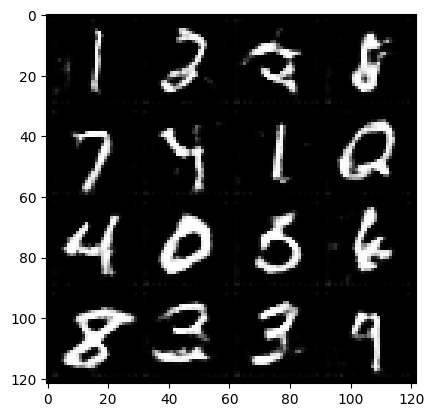

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [4/50] Loss D: 0.5941, Loss G: 0.8797


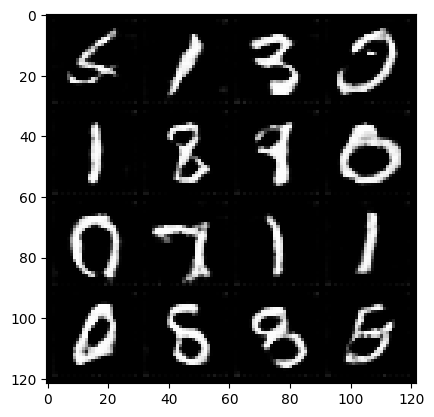

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [5/50] Loss D: 0.5804, Loss G: 1.1582


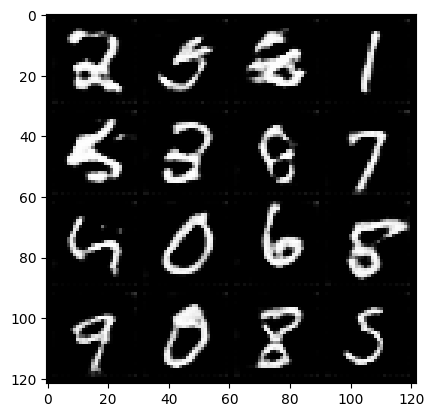

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [6/50] Loss D: 0.6221, Loss G: 0.9258


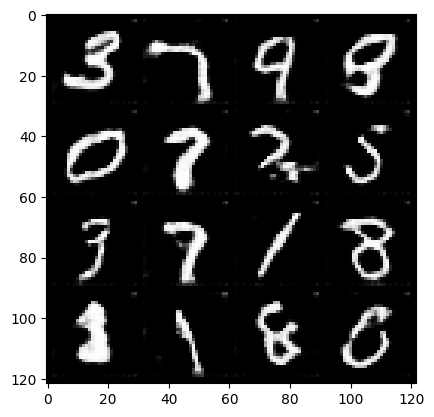

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [7/50] Loss D: 0.6298, Loss G: 0.8949


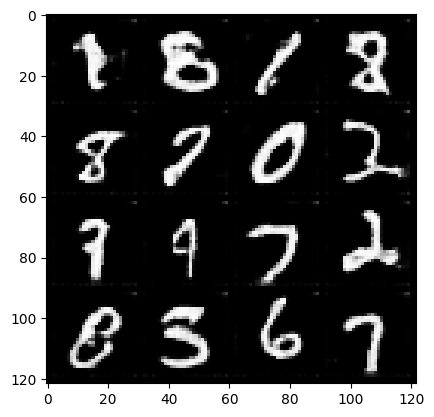

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [8/50] Loss D: 0.5458, Loss G: 0.8020


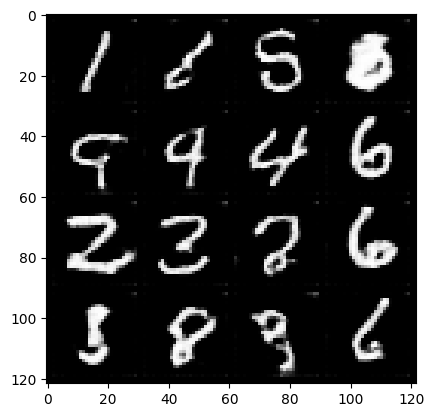

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [9/50] Loss D: 0.5866, Loss G: 0.9272


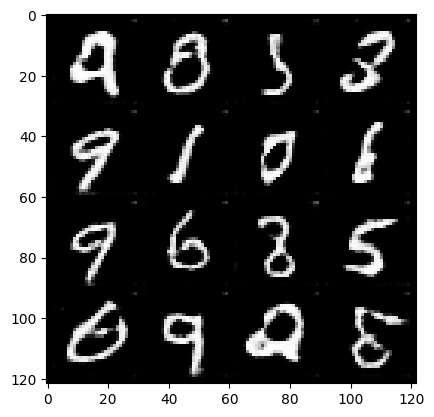

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [10/50] Loss D: 0.5251, Loss G: 1.0895


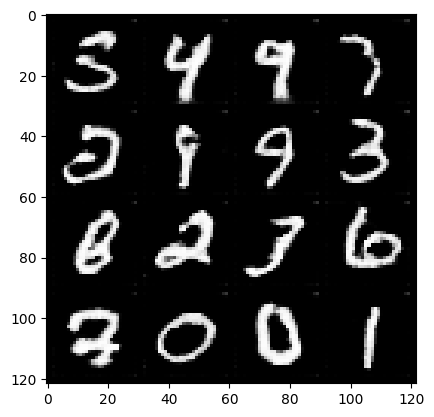

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [11/50] Loss D: 0.5546, Loss G: 1.1085


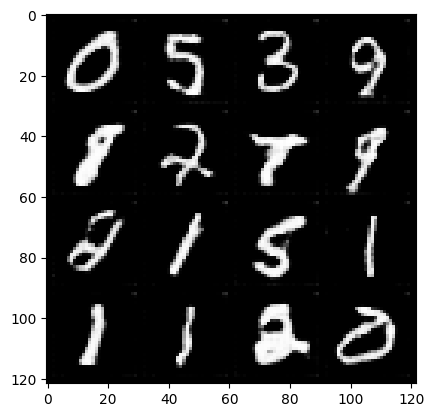

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [12/50] Loss D: 0.5776, Loss G: 1.1837


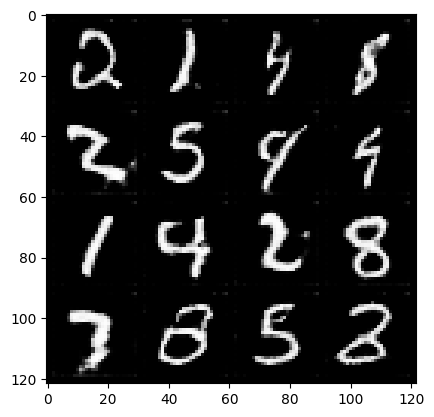

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [13/50] Loss D: 0.5730, Loss G: 1.2052


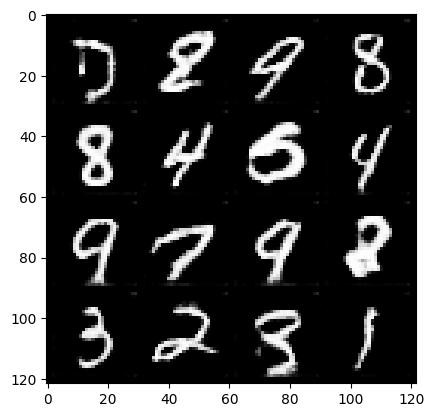

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [14/50] Loss D: 0.5888, Loss G: 0.8534


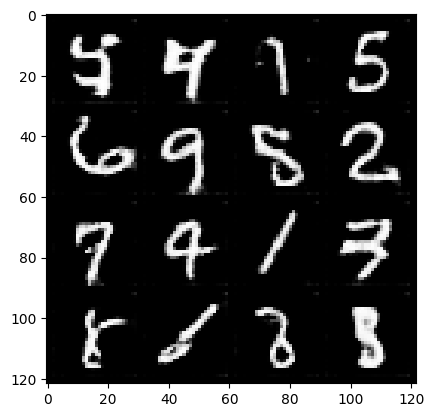

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [15/50] Loss D: 0.5528, Loss G: 1.2236


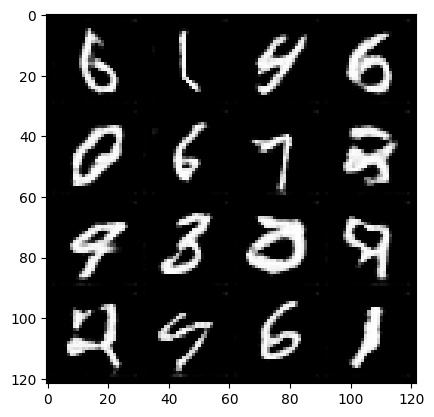

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [16/50] Loss D: 0.6146, Loss G: 0.8252


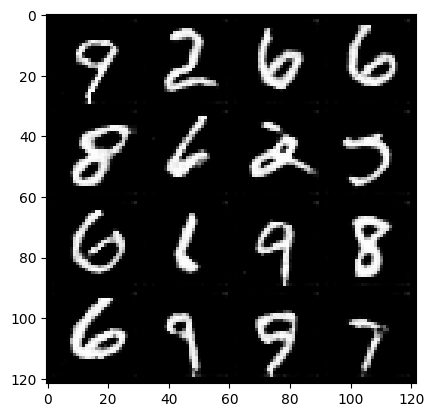

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [17/50] Loss D: 0.5140, Loss G: 1.0167


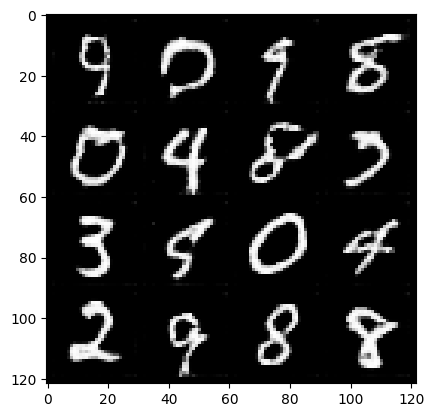

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [18/50] Loss D: 0.5776, Loss G: 0.8312


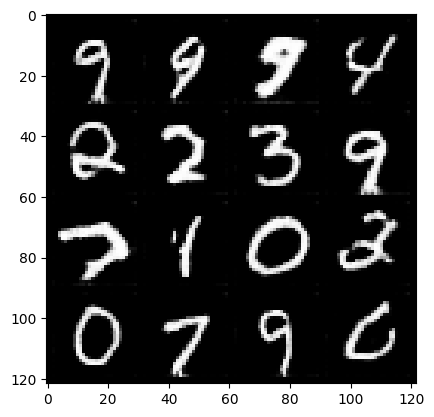

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [19/50] Loss D: 0.5532, Loss G: 0.8221


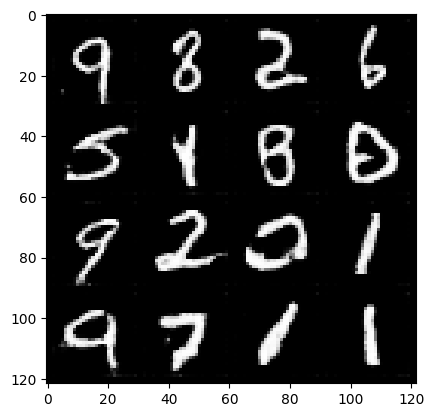

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [20/50] Loss D: 0.5904, Loss G: 1.2098


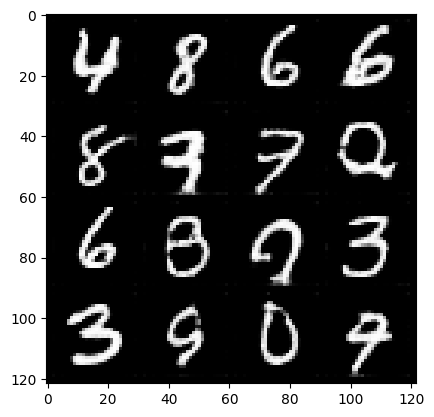

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [21/50] Loss D: 0.5956, Loss G: 1.2742


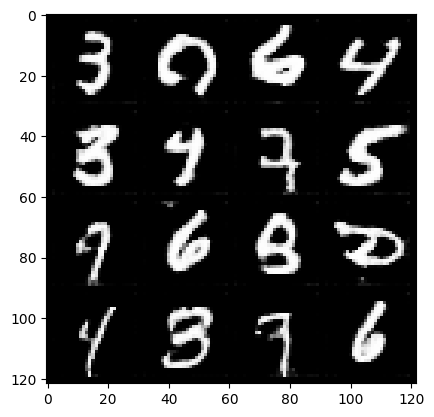

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [22/50] Loss D: 0.5819, Loss G: 1.1806


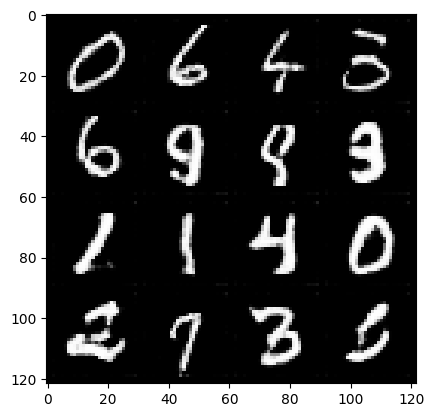

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [23/50] Loss D: 0.5167, Loss G: 0.9772


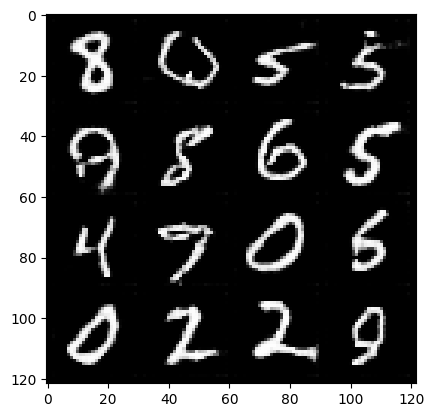

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [24/50] Loss D: 0.5987, Loss G: 1.0213


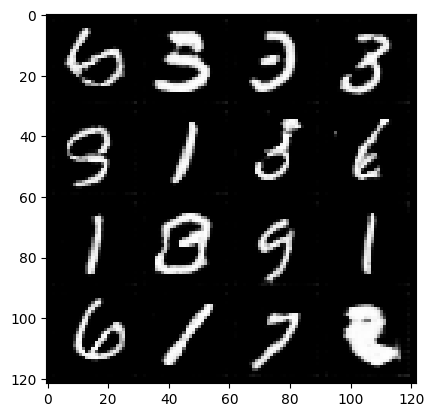

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [25/50] Loss D: 0.6107, Loss G: 1.3192


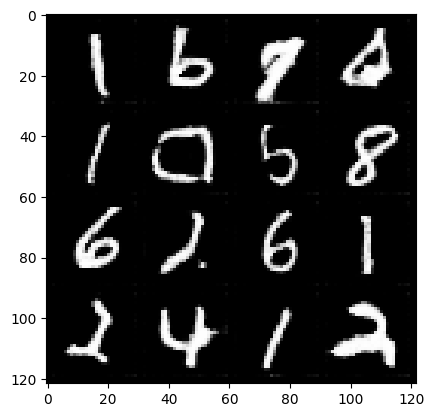

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [26/50] Loss D: 0.6270, Loss G: 1.3975


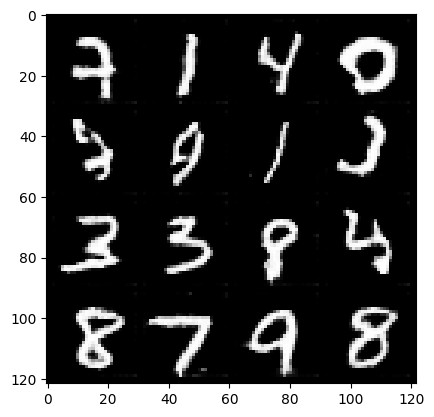

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [27/50] Loss D: 0.4779, Loss G: 1.0576


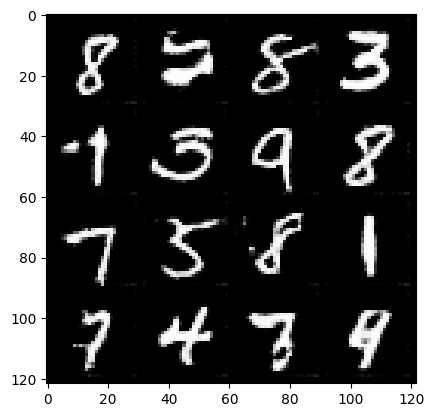

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [28/50] Loss D: 0.5935, Loss G: 0.9781


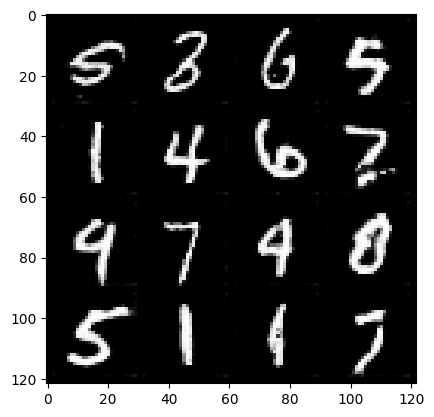

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [29/50] Loss D: 0.5026, Loss G: 0.8632


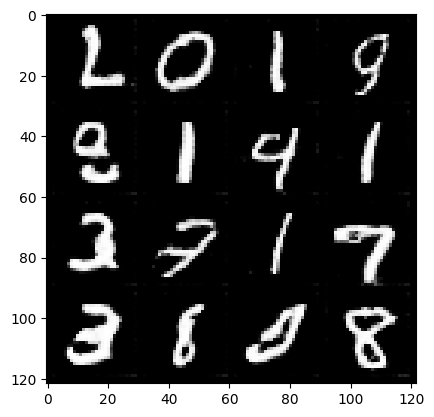

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [30/50] Loss D: 0.5233, Loss G: 1.0180


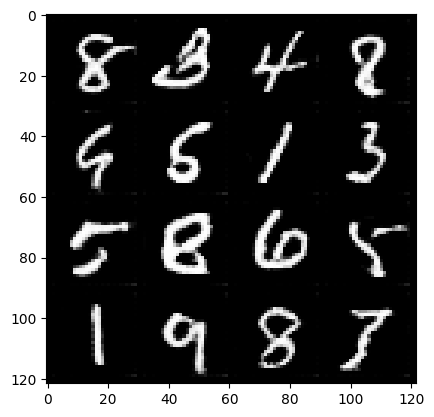

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [31/50] Loss D: 0.4687, Loss G: 1.0376


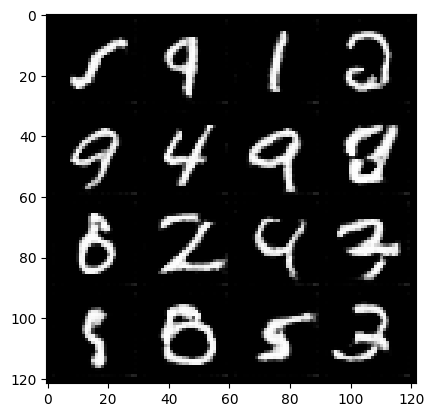

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [32/50] Loss D: 0.5382, Loss G: 1.1998


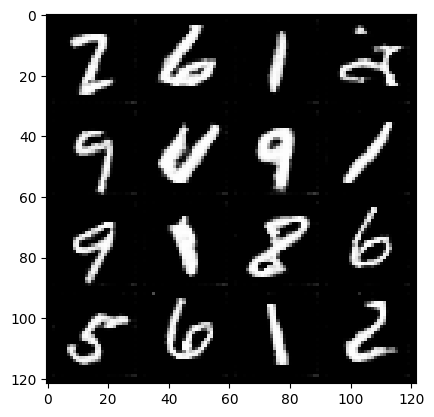

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [33/50] Loss D: 0.4885, Loss G: 0.7647


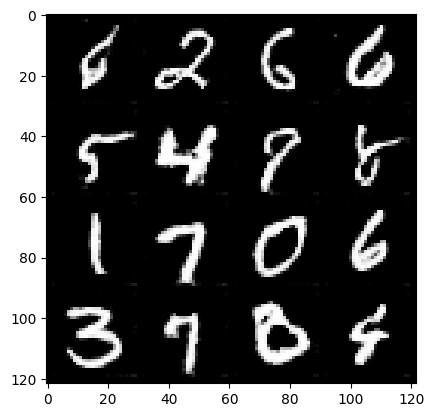

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [34/50] Loss D: 0.5456, Loss G: 1.0369


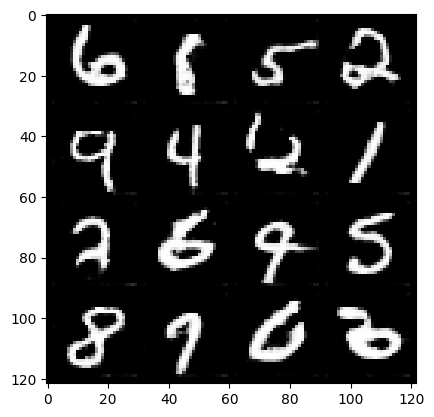

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [35/50] Loss D: 0.5508, Loss G: 0.9131


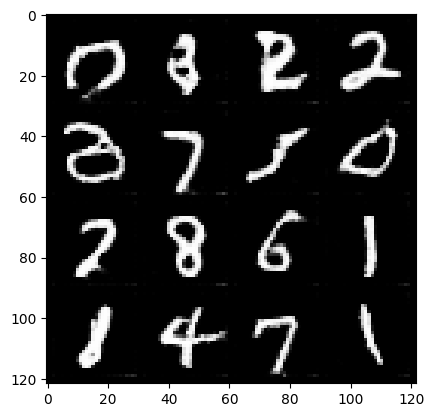

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [36/50] Loss D: 0.5855, Loss G: 1.1491


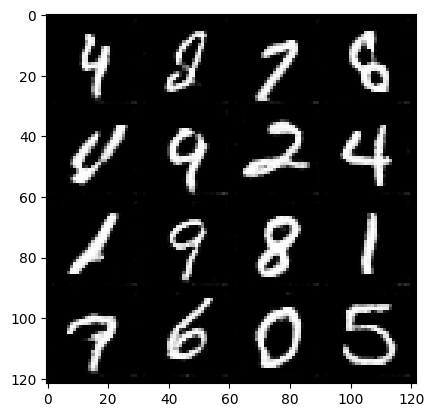

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [37/50] Loss D: 0.5605, Loss G: 0.8842


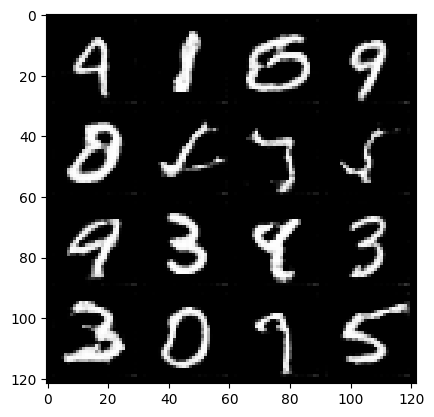

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [38/50] Loss D: 0.5022, Loss G: 1.2325


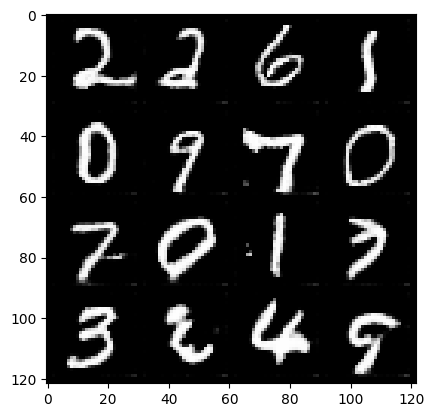

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [39/50] Loss D: 0.7822, Loss G: 1.1277


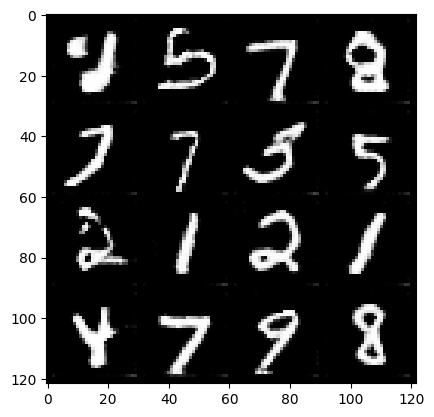

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [40/50] Loss D: 0.5467, Loss G: 1.4541


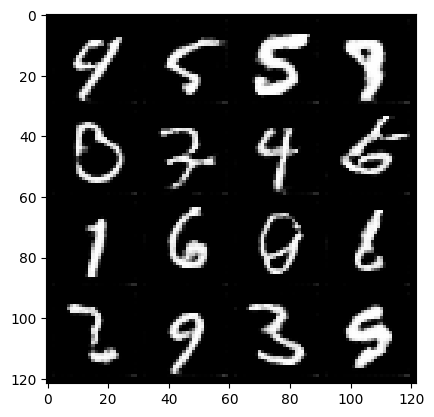

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [41/50] Loss D: 0.4939, Loss G: 1.3018


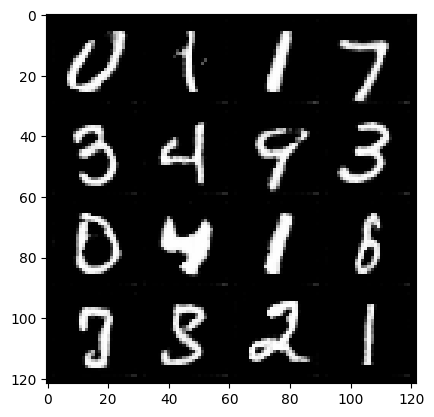

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [42/50] Loss D: 0.6369, Loss G: 0.7646


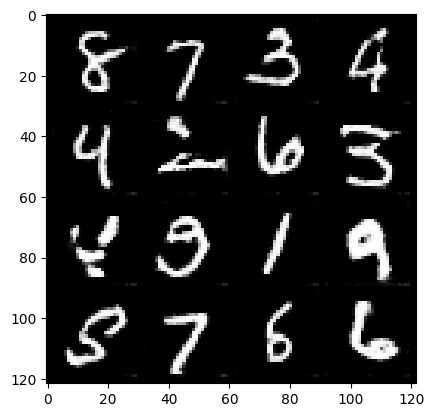

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [43/50] Loss D: 0.4384, Loss G: 0.7822


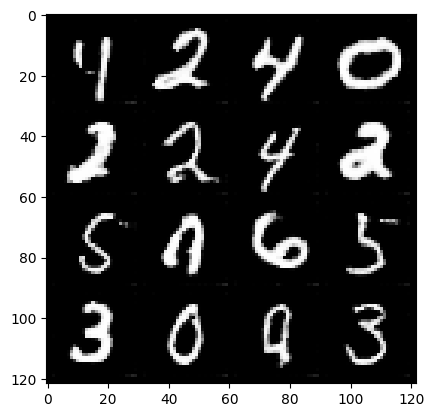

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [44/50] Loss D: 0.5928, Loss G: 0.8693


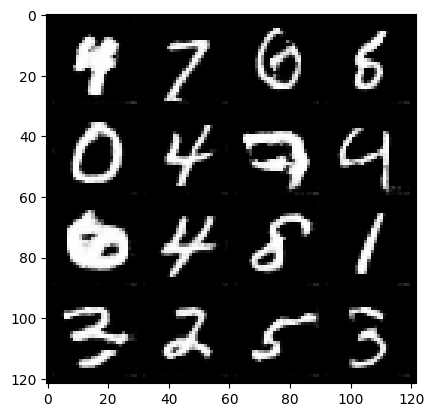

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [45/50] Loss D: 0.5890, Loss G: 0.8674


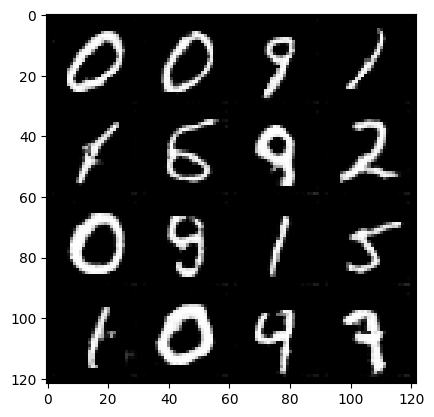

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [46/50] Loss D: 0.6187, Loss G: 0.7515


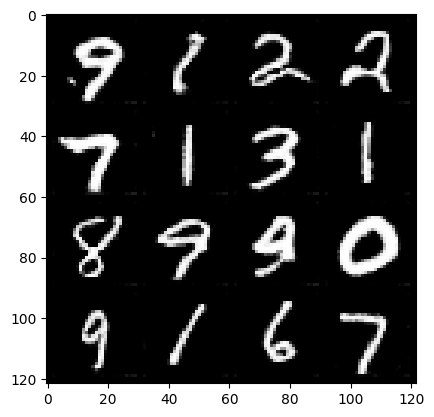

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [47/50] Loss D: 0.5970, Loss G: 0.9548


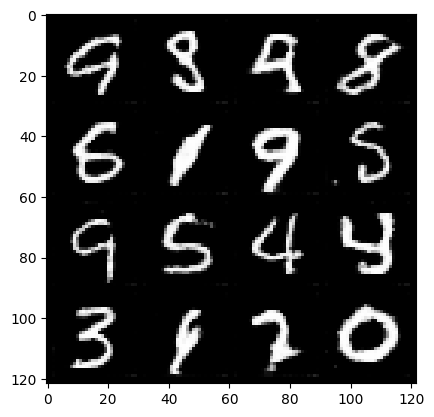

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [48/50] Loss D: 0.6652, Loss G: 1.2980


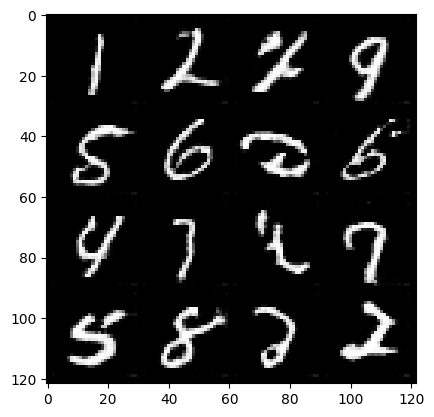

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [49/50] Loss D: 0.4854, Loss G: 0.9421


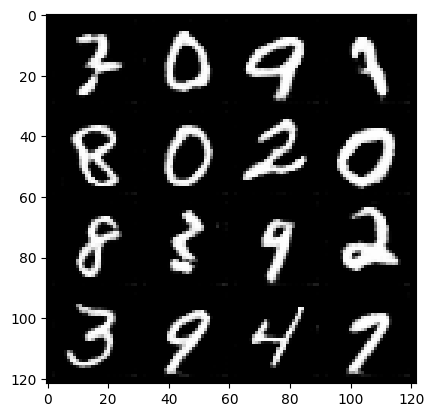

Trained Generator model saved to 'generator_model.pth'


In [13]:
for epoch in range(num_epochs):
    for real_images, _ in tqdm(train_loader):
        real_images = real_images.to(device)
        cur_batch_size = real_images.shape[0]

        ### Train Discriminator
        # Generate fake images
        noise = torch.randn(cur_batch_size, noise_dim, 1, 1, device=device)
        fake_images = G(noise)

        # Discriminator predictions
        D_real = D(real_images).reshape(-1)
        D_fake = D(fake_images.detach()).reshape(-1)

        # Calculate Discriminator loss
        loss_D_real = loss_function(D_real, torch.ones_like(D_real))
        loss_D_fake = loss_function(D_fake, torch.zeros_like(D_fake))
        loss_D = (loss_D_real + loss_D_fake) / 2

        # Backpropagation for Discriminator
        optimizer_D.zero_grad()
        loss_D.backward()
        optimizer_D.step()

        ### Train Generator
        # Generate new fake images
        noise = torch.randn(cur_batch_size, noise_dim, 1, 1, device=device)
        fake_images = G(noise)

        # Discriminator predictions on new fake images
        D_fake_new = D(fake_images).reshape(-1)

        # Calculate Generator loss
        loss_G = loss_function(D_fake_new, torch.ones_like(D_fake_new))

        # Backpropagation for Generator
        optimizer_G.zero_grad()
        loss_G.backward()
        optimizer_G.step()

    # Log and visualize progress
    print(f"Epoch [{epoch}/{num_epochs}] Loss D: {loss_D.item():.4f}, Loss G: {loss_G.item():.4f}")
    # Display some generated images after each epoch (or periodically)
    with torch.no_grad():
        noise = torch.randn(batch_size, noise_dim, 1, 1, device=device)
        generated_images = G(noise)
        show_tensor_images(generated_images)

# Save the Generator's state dictionary after training
torch.save(G.state_dict(), 'generator_model.pth')
print("Trained Generator model saved to 'generator_model.pth'")

Trained Generator model loaded successfully.
Generated images from the loaded model:


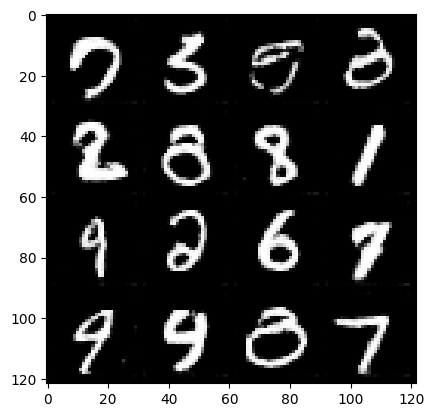

In [14]:
# Load the trained Generator model and generate new images

# Initialize a new Generator instance (make sure hyperparameters match the training)
loaded_G = Generator(noise_dim, image_channels).to(device)

# Load the saved state dictionary
loaded_G.load_state_dict(torch.load('generator_model.pth'))

# Set the model to evaluation mode (important for inference)
loaded_G.eval()

print("Trained Generator model loaded successfully.")

# Generate new noise
noise = torch.randn(batch_size, noise_dim, 1, 1, device=device)

# Generate images using the loaded model
with torch.no_grad():
    generated_images_from_loaded_model = loaded_G(noise)

# Display the generated images
print("Generated images from the loaded model:")
show_tensor_images(generated_images_from_loaded_model)